<a href="https://colab.research.google.com/github/LesTa98/northstar-data-analysis/blob/main/notebooks/02_r_sql_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
df <- read.csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/cleaned/cleaned_dataset.csv")

In [3]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")

library(sqldf)
library(ggplot2)
library(dplyr)
library(tidyr)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




SQL QUERIES

1. Total deliveries, avg delay, failed, complaints per hub

Calculates total deliveries, average delay, failed deliveries, and complaints for each hub.

In [4]:
sqldf("SELECT hub_name,
       COUNT(*) AS total_deliveries,
       AVG(delay_minutes) AS avg_delay,
       SUM(CASE WHEN delivery_status='Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       SUM(has_complaint) AS complaints
FROM df
GROUP BY hub_name;")

hub_name,total_deliveries,avg_delay,failed_deliveries,complaints
<chr>,<int>,<dbl>,<int>,<dbl>
Airport Hub,104,543.5441,15,21
Central Core,115,650.9957,23,28
East Dock,119,455.2133,11,31
Midtown Relay,128,584.1191,26,31
North Exchange,136,556.2396,17,26
Riverside Hub,115,593.6668,14,30
South Link,106,520.4407,10,16
West Gate,127,608.4516,16,26


2. Top 10 drivers by total deliveries

Retrieves the top 10 drivers based on total deliveries along with their average rating, failed deliveries, and incident count.

In [5]:
top_drivers <- sqldf("SELECT driver_id,
       COUNT(*) AS total_deliveries,
       AVG(customer_rating_post_delivery) AS avg_rating,
       SUM(CASE WHEN delivery_status='Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       SUM(incident_count) AS total_incidents
FROM df
GROUP BY driver_id
ORDER BY total_deliveries DESC
LIMIT 10;")

3. Vehicle performance

Analyses each vehicle’s deliveries, average fuel cost, odometer usage, battery health, and maintenance issues.

In [6]:
sqldf("SELECT vehicle_id, vehicle_type,
       COUNT(*) AS total_deliveries,
       AVG(fuel_or_charge_cost) AS avg_fuel_cost,
       AVG(odometer_km) AS avg_odometer,
       AVG(battery_health_pct) AS avg_battery_health,
       SUM(CASE WHEN maintenance_status != 'Active' THEN 1 ELSE 0 END) AS maintenance_issues
FROM df
GROUP BY vehicle_id, vehicle_type;")

vehicle_id,vehicle_type,total_deliveries,avg_fuel_cost,avg_odometer,avg_battery_health,maintenance_issues
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
V001,EV,10,12.94200,56928,71.80,0
V002,EV,8,15.16375,159368,67.90,8
V003,CargoVan,1,7.74000,219359,91.70,0
V004,Hybrid,10,12.12200,36310,78.05,0
V005,CargoVan,13,15.47385,146638,58.60,0
V006,EV,9,16.49111,141381,78.60,0
V007,Diesel,9,12.21667,78468,68.60,0
V008,EV,9,14.75000,49711,90.50,0
V009,CargoVan,9,11.31667,156687,68.80,0


4. Customer insights

Summarises total orders, average order value, loyalty, engagement, and complaints for each customer.

In [7]:
sqldf("SELECT customer_id, customer_type,
       COUNT(*) AS total_orders,
       AVG(order_value) AS avg_order_value,
       MAX(loyalty_score) AS loyalty_score,
       MAX(app_engagement_score) AS engagement_score,
       SUM(has_complaint) AS complaints
FROM df
GROUP BY customer_id, customer_type;")

customer_id,customer_type,total_orders,avg_order_value,loyalty_score,engagement_score,complaints
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
C0001,SME,2,130.72000,44.9,69.2,2
C0002,Consumer,1,135.53000,55.4,66.6,0
C0004,Consumer,2,143.48000,32.5,33.0,1
C0005,Consumer,1,58.30000,55.9,100.0,0
C0006,Consumer,3,76.19333,39.9,43.3,0
C0009,Consumer,1,84.27000,62.6,40.8,0
C0010,Consumer,1,23.34000,87.2,48.6,0
C0012,Consumer,3,123.66333,46.3,74.4,1
C0013,Enterprise,3,104.06667,31.3,51.7,1


5. Risk & delay by priority level

Compares average delay, risk score, failed deliveries, and complaints across priority levels.

In [8]:
sqldf("SELECT priority_level,
       AVG(delay_minutes) AS avg_delay,
       AVG(risk_score) AS avg_risk,
       SUM(CASE WHEN delivery_status='Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
       SUM(has_complaint) AS complaints
FROM df
GROUP BY priority_level;
")

priority_level,avg_delay,avg_risk,failed_deliveries,complaints
<chr>,<dbl>,<dbl>,<int>,<dbl>
Critical,435.5818,1.655405,3,18
High,596.0646,1.891775,32,51
Low,534.2288,1.577220,34,54
Medium,591.7146,1.772021,63,86


6. High value orders

 Lists the top 10 highest-value orders along with customer and priority details.

In [9]:
sqldf("SELECT order_id, customer_id, order_value, priority_level
FROM df
ORDER BY order_value DESC
LIMIT 10;")

order_id,customer_id,order_value,priority_level
<chr>,<chr>,<dbl>,<chr>
O00980,C0545,510.06,Medium
O00892,C0157,326.38,Medium
O01207,C0197,321.68,Medium
O00013,C0234,302.70,Medium
O01145,C0548,301.38,Medium
O00052,C0150,293.65,Medium
O00860,C0076,292.33,Medium
O00144,C0063,288.86,High
O00472,C0636,287.30,Medium


7. Deliveries per vehicle type per zone

Counts how many deliveries are made by each vehicle type in each assigned zone.

In [10]:
sqldf("SELECT vehicle_type, assigned_zone, COUNT(*) AS total_deliveries
FROM df
GROUP BY vehicle_type, assigned_zone;")

vehicle_type,assigned_zone,total_deliveries
<chr>,<chr>,<int>
CargoVan,Airport,14
CargoVan,Central,28
CargoVan,Ctr,5
CargoVan,East,31
CargoVan,North,69
CargoVan,Riverside,18
CargoVan,South,25
CargoVan,West,33
Diesel,Airport,24


8. Complaints by booking channel

 Shows the total number of complaints grouped by booking channel (e.g., App, Web).

In [11]:
sqldf("SELECT booking_channel, SUM(has_complaint) AS total_complaints
FROM df
GROUP BY booking_channel;
")

booking_channel,total_complaints
<chr>,<dbl>
API,12
App,114
Phone,34
Unknown,7
Web,42


9. Count of delayed vs on-time deliveries

Counts how many deliveries are delayed versus on-time using a conditional flag.

In [12]:
sqldf("SELECT CASE WHEN delay_minutes>0 THEN 'Delayed' ELSE 'OnTime' END AS delay_flag,
       COUNT(*) AS total_deliveries
FROM df
GROUP BY delay_flag;")

delay_flag,total_deliveries
<chr>,<int>
Delayed,867
OnTime,83


10. Top 10 customers by total order value

Identifies the top 10 customers based on their total spending across all orders.


In [13]:
sqldf("SELECT customer_id, SUM(order_value) AS total_value
FROM df
GROUP BY customer_id
ORDER BY total_value DESC
LIMIT 10;")

customer_id,total_value
<chr>,<dbl>
C0545,834.75
C0157,720.04
C0622,609.88
C0550,543.02
C0023,542.11
C0289,498.90
C0558,492.28
C0530,477.16
C0548,473.05






R ANALYTICS






Queries

1. Delivery performance by hub

Summarises the total deliveries, average delay, failed deliveries, and complaints for each hub.


In [14]:
delivery_hub_summary <- df %>%
  group_by(hub_name) %>%
  summarise(
    total_deliveries = n(),
    avg_delay = mean(delay_minutes),
    failed_deliveries = sum(delivery_status == "Failed"),
    complaints = sum(has_complaint)
  )
delivery_hub_summary

hub_name,total_deliveries,avg_delay,failed_deliveries,complaints
<chr>,<int>,<dbl>,<int>,<dbl>
Airport Hub,104,543.5441,15,21
Central Core,115,650.9957,23,28
East Dock,119,455.2133,11,31
Midtown Relay,128,584.1191,26,31
North Exchange,136,556.2396,17,26
Riverside Hub,115,593.6668,14,30
South Link,106,520.4407,10,16
West Gate,127,608.4516,16,26


2. Driver Performance

Shows total deliveries, average customer rating, average delay, failed deliveries, and incident count per driver.

In [15]:
driver_summary <- df %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries = n(),
    avg_customer_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    avg_delay = mean(delay_minutes),
    failed_deliveries = sum(delivery_status == "Failed"),
    incident_count = sum(incident_count)
  )%>%
  arrange(desc(total_deliveries))
driver_summary

driver_id,total_deliveries,avg_customer_rating,avg_delay,failed_deliveries,incident_count
<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>
D102,13,4.138462,367.0064,0,3
D087,12,3.825000,541.8167,2,6
D119,12,4.027500,564.1833,1,4
D133,12,3.423333,603.7319,4,3
D026,11,4.079091,880.1970,0,5
D108,11,4.411818,482.9833,3,4
D017,10,3.679000,521.8517,2,3
D049,10,3.761000,563.4817,2,3
D055,10,3.813000,1109.5117,3,1


3. Vehicle analysis


Calculates total deliveries, average fuel/charge cost, average odometer reading, average battery health, and maintenance issues per vehicle.

In [16]:
vehicle_summary <- df %>%
  group_by(vehicle_id, vehicle_type) %>%
  summarise(
    total_deliveries = n(),
    avg_fuel_or_charge_cost = mean(fuel_or_charge_cost),
    avg_odometer_km = mean(odometer_km),
    avg_battery_health = mean(battery_health_pct, na.rm = TRUE),
    maintenance_issues = sum(maintenance_status != "Active")
  )
vehicle_summary

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by vehicle_id and vehicle_type.
ℹ Output is grouped by vehicle_id.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(vehicle_id, vehicle_type))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


vehicle_id,vehicle_type,total_deliveries,avg_fuel_or_charge_cost,avg_odometer_km,avg_battery_health,maintenance_issues
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
V001,EV,10,12.94200,56928,71.80,0
V002,EV,8,15.16375,159368,67.90,8
V003,CargoVan,1,7.74000,219359,91.70,0
V004,Hybrid,10,12.12200,36310,78.05,0
V005,CargoVan,13,15.47385,146638,58.60,0
V006,EV,9,16.49111,141381,78.60,0
V007,Diesel,9,12.21667,78468,68.60,0
V008,EV,9,14.75000,49711,90.50,0
V009,CargoVan,9,11.31667,156687,68.80,0


4. Customer analysis

Provides total orders, average order value, loyalty score, app engagement, and complaints for each customer.

In [17]:
customer_summary <- df %>%
  group_by(customer_id, customer_type) %>%
  summarise(
    total_orders = n(),
    avg_order_value = mean(order_value),
    loyalty_score = first(loyalty_score),
    app_engagement_score = first(app_engagement_score),
    complaints = sum(has_complaint)
  )
customer_summary

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by customer_id and customer_type.
ℹ Output is grouped by customer_id.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(customer_id, customer_type))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


customer_id,customer_type,total_orders,avg_order_value,loyalty_score,app_engagement_score,complaints
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
C0001,SME,2,130.72000,44.9,69.2,2
C0002,Consumer,1,135.53000,55.4,66.6,0
C0004,Consumer,2,143.48000,32.5,33.0,1
C0005,Consumer,1,58.30000,55.9,100.0,0
C0006,Consumer,3,76.19333,39.9,43.3,0
C0009,Consumer,1,84.27000,62.6,40.8,0
C0010,Consumer,1,23.34000,87.2,48.6,0
C0012,Consumer,3,123.66333,46.3,74.4,1
C0013,Enterprise,3,104.06667,31.3,51.7,1


5. Risk and delay analysis

Reports average delay, average risk score, failed deliveries, and complaints grouped by priority level.

In [18]:
risk_summary <- df %>%
  group_by(priority_level) %>%
  summarise(
    avg_delay = mean(delay_minutes),
    avg_risk = mean(risk_score),
    failed_deliveries = sum (delivery_status == "Failed"),
    complaints = sum(has_complaint)
  )
risk_summary

priority_level,avg_delay,avg_risk,failed_deliveries,complaints
<chr>,<dbl>,<dbl>,<int>,<dbl>
Critical,435.5818,1.655405,3,18
High,596.0646,1.891775,32,51
Low,534.2288,1.577220,34,54
Medium,591.7146,1.772021,63,86


6. Correlation: delay vs complaints

Measures how delivery delays relate to complaints and customer ratings.

In [19]:
corr_delay_complaint <- cor(df$delay_minutes, df$has_complaint)
corr_delay_complaint

corr_delay_rating <- cor(df$delay_minutes, df$customer_rating_post_delivery, use = "complete.obs")
corr_delay_rating

[1] 0.02475584

[1] -0.293762

7. Overall KPI summary

This query calculates NorthStar’s overall operational KPIs, including total deliveries, average delay, delay rate, failure rate, complaint rate, customer rating, and incident rate to summarise overall delivery performance.

In [21]:
kpi_summary <- df %>%
  summarise(
    total_deliveries = n(),
    avg_delay_minutes = round(mean(delay_minutes, na.rm = TRUE), 2),
    delayed_deliveries = sum(delay_minutes > 0, na.rm = TRUE),
    delayed_rate_pct = round((delayed_deliveries / total_deliveries) * 100, 2),
    failed_deliveries = sum(delivery_status == "Failed", na.rm = TRUE),
    failed_rate_pct = round((failed_deliveries / total_deliveries) * 100, 2),
    total_complaints = sum(has_complaint, na.rm = TRUE),
    complaint_rate_pct = round((total_complaints / total_deliveries) * 100, 2),
    avg_customer_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    total_incidents = sum(incident_count, na.rm = TRUE),
    incident_rate_per_delivery = round(total_incidents / total_deliveries, 3)
  )

kpi_summary

total_deliveries,avg_delay_minutes,delayed_deliveries,delayed_rate_pct,failed_deliveries,failed_rate_pct,total_complaints,complaint_rate_pct,avg_customer_rating,total_incidents,incident_rate_per_delivery
<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
950,564.94,867,91.26,132,13.89,209,22,3.87,280,0.295


R Visualisations

1. Delivery Status Distribution

Compares the count of OnTime, Delayed, and Failed deliveries.

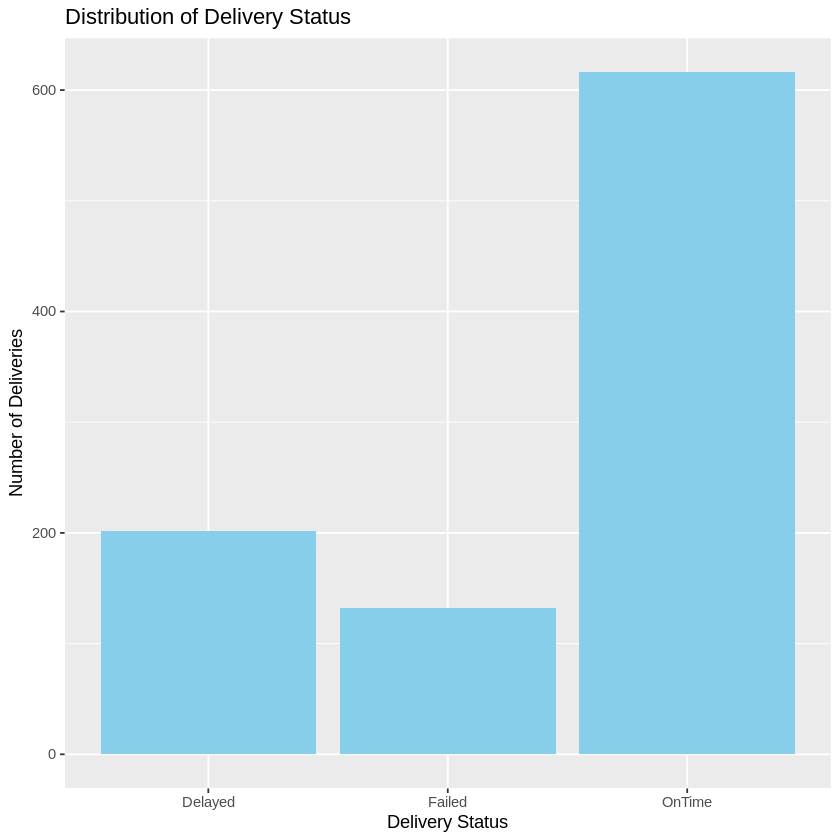

In [22]:
ggplot(df, aes(x=delivery_status)) +
  geom_bar(fill="skyblue") +
  labs(
    title = "Distribution of Delivery Status",
    x = "Delivery Status",
    y = "Number of Deliveries"
  )

2. Delays by hub

Shows the distribution of delivery delays for each hub using a boxplot.

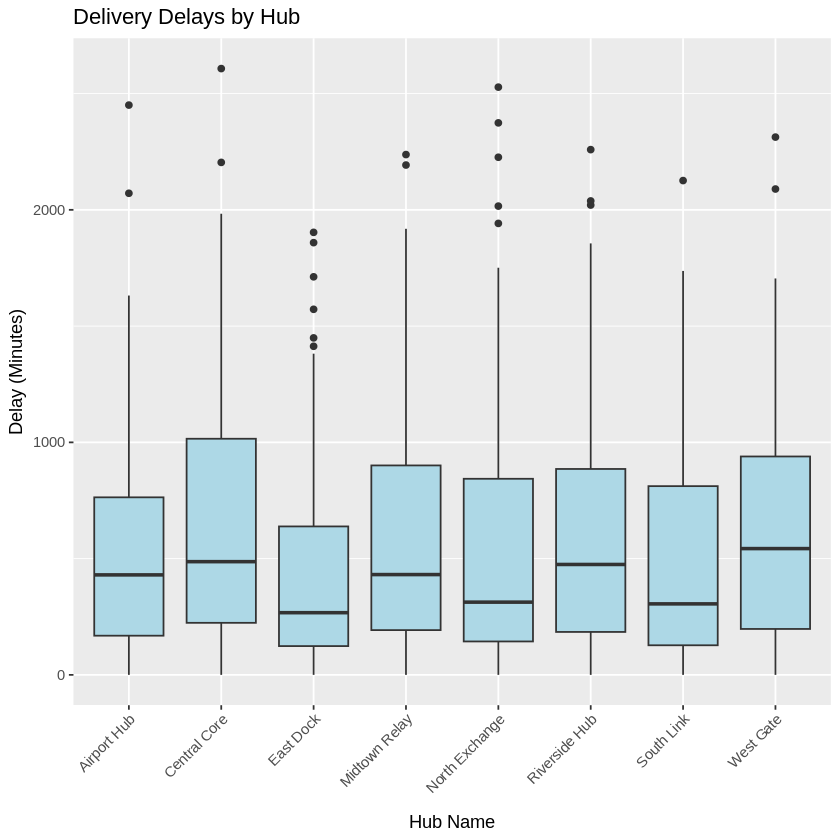

In [23]:
ggplot(df, aes(x=hub_name, y=delay_minutes)) +
  geom_boxplot(fill="lightblue") +
  labs(
    title = "Delivery Delays by Hub",
    x = "Hub Name",
    y = "Delay (Minutes)"
  ) +
  theme(axis.text.x = element_text(angle=45, hjust=1))

3. Top drivers by Average rating

Highlights the highest-rated drivers in terms of customer feedback.

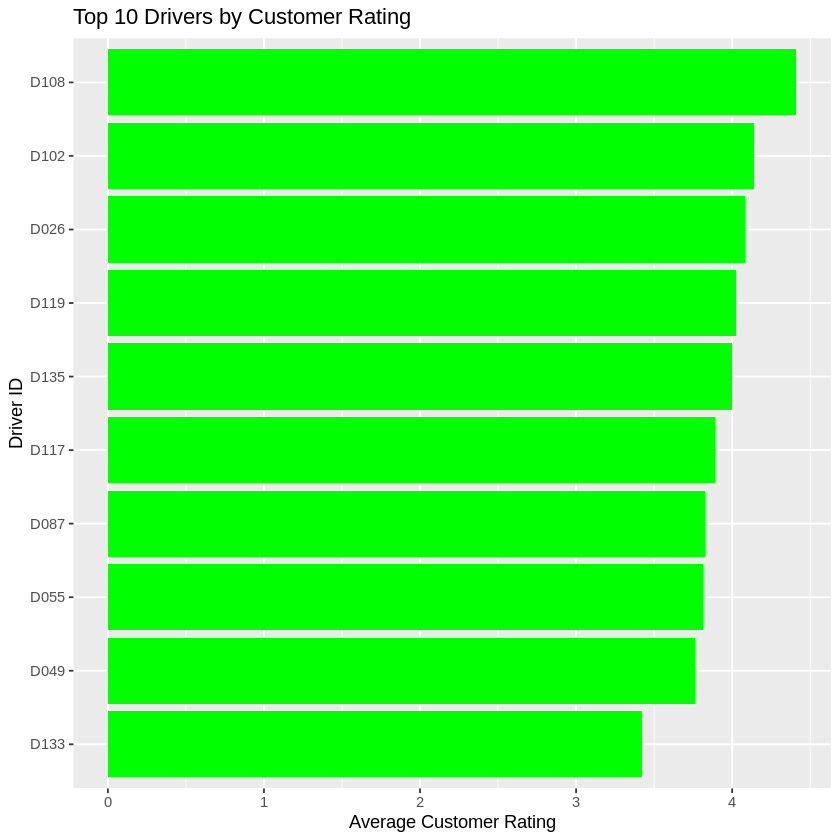

In [31]:
ggplot(top_drivers, aes(x=reorder(driver_id, avg_rating), y=avg_rating)) +
  geom_col(fill="green") +
  coord_flip() +
  labs(
    title = "Top 10 Drivers by Customer Rating",
    x = "Driver ID",
    y = "Average Customer Rating"
  )


4. Delay vs customer rating

Shows the relationships between delivery delays and customer ratings using a scatter plot with a trend line.

`geom_smooth()` using formula = 'y ~ x'


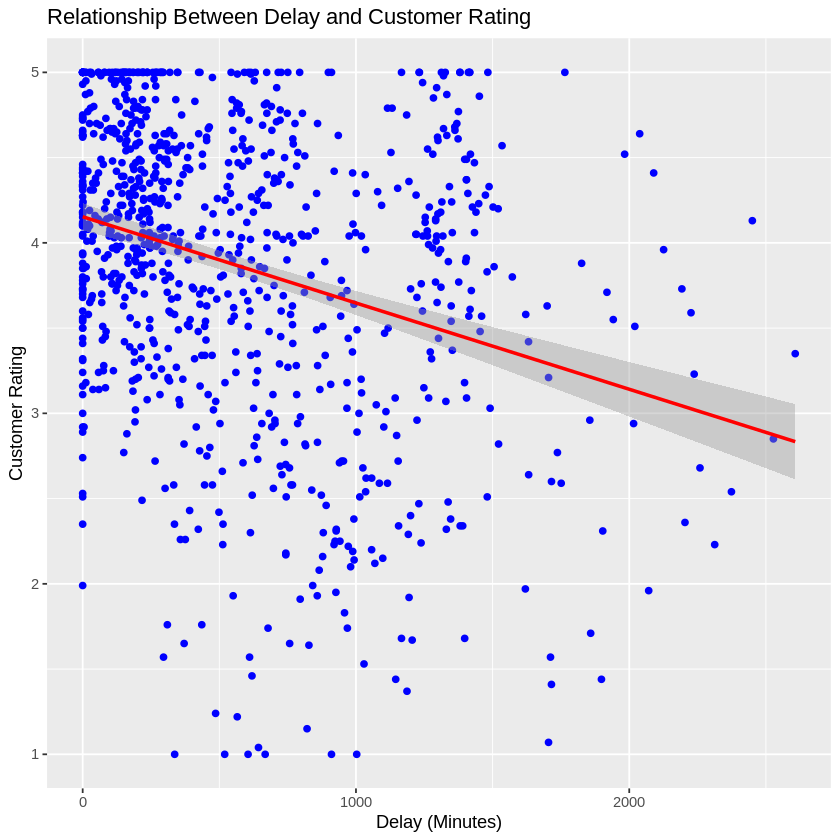

In [25]:
ggplot(df, aes(x=delay_minutes, y=customer_rating_post_delivery)) +
  geom_point(color="blue") +
  geom_smooth(method="lm", color="red") +
  labs(
    title = "Relationship Between Delay and Customer Rating",
    x = "Delay (Minutes)",
    y = "Customer Rating"
  )

5. Risk score by priority level

Compares the average risk score across different priority levels.

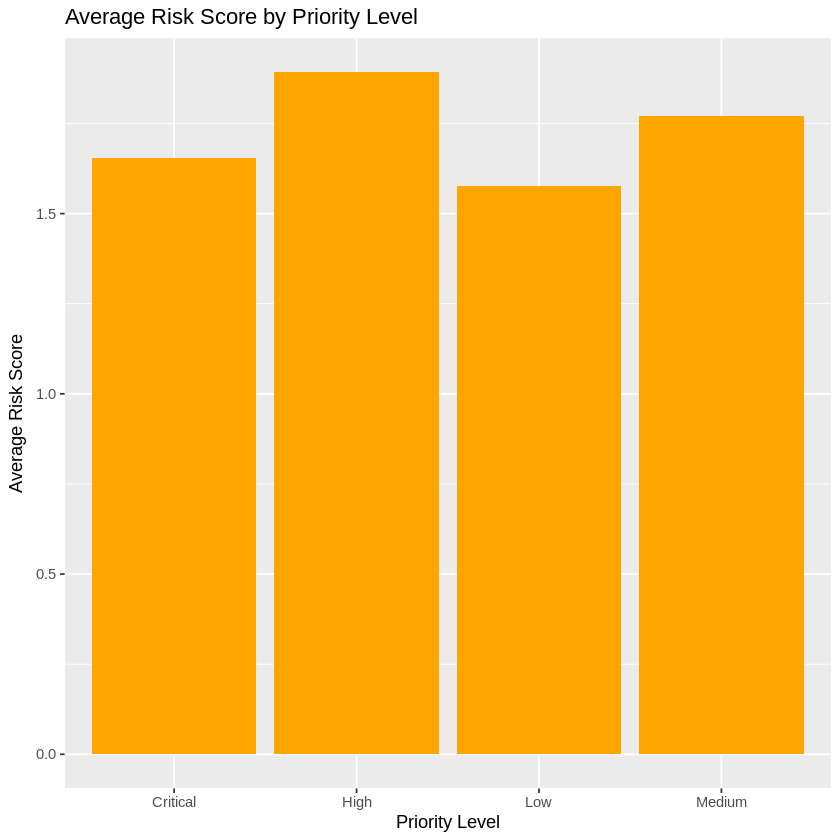

In [26]:
ggplot(risk_summary, aes(x=priority_level, y=avg_risk)) +
  geom_col(fill="orange") +
  labs(
    title = "Average Risk Score by Priority Level",
    x = "Priority Level",
    y = "Average Risk Score"
  )

6. Route distance vs Fuel/Charge cost

Illustrates how delivery distance affects fuel or charging costs using a scatter plot with a trend line.

`geom_smooth()` using formula = 'y ~ x'


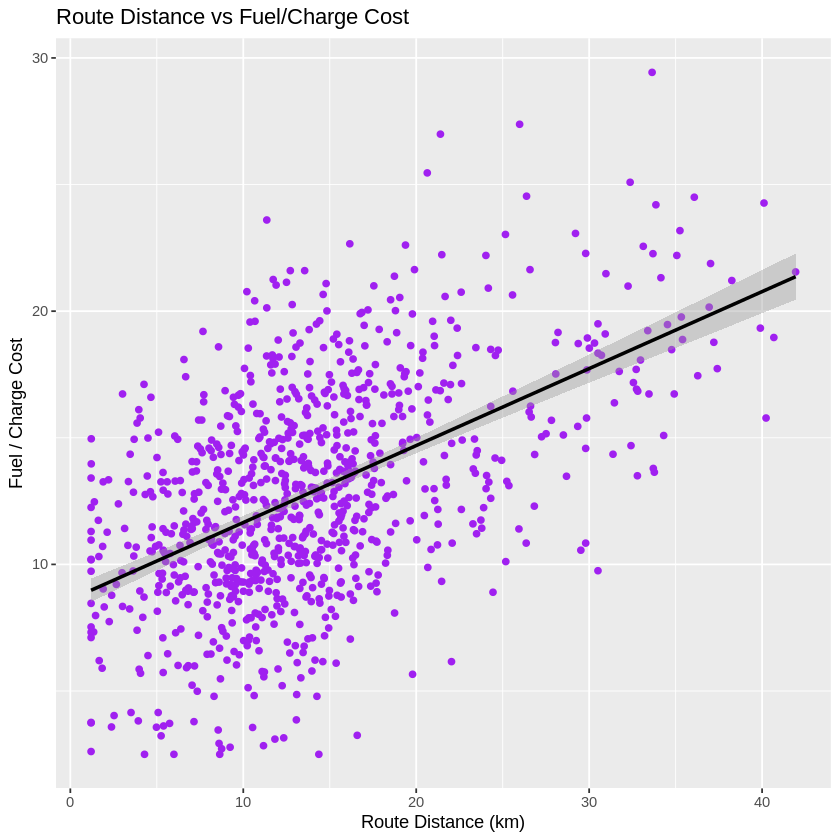

In [27]:
ggplot(df, aes(x=route_distance_km, y=fuel_or_charge_cost)) +
  geom_point(color="purple") +
  geom_smooth(method="lm", color="black") +
  labs(
    title = "Route Distance vs Fuel/Charge Cost",
    x = "Route Distance (km)",
    y = "Fuel / Charge Cost"
  )

7. Overall KPI summary

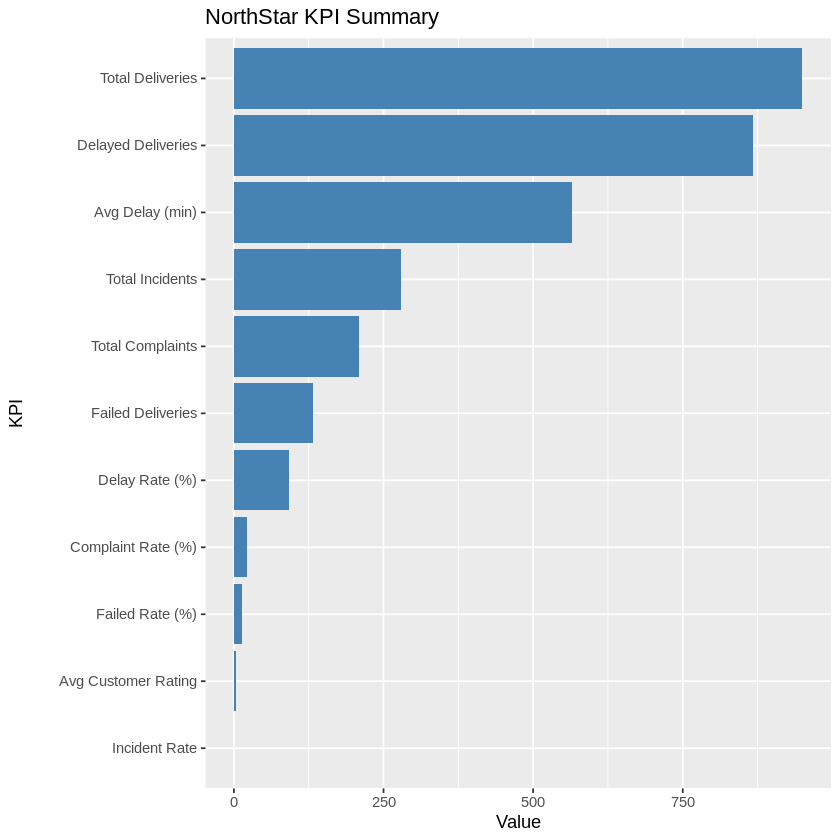

In [29]:
kpi_summary_renamed <- kpi_summary %>%
  rename(
    "Total Deliveries" = total_deliveries,
    "Avg Delay (min)" = avg_delay_minutes,
    "Delayed Deliveries" = delayed_deliveries,
    "Delay Rate (%)" = delayed_rate_pct,
    "Failed Deliveries" = failed_deliveries,
    "Failed Rate (%)" = failed_rate_pct,
    "Total Complaints" = total_complaints,
    "Complaint Rate (%)" = complaint_rate_pct,
    "Avg Customer Rating" = avg_customer_rating,
    "Total Incidents" = total_incidents,
    "Incident Rate" = incident_rate_per_delivery
  )
kpi_plot <- kpi_summary_renamed %>%
  pivot_longer(cols = everything(),
               names_to = "KPI",
               values_to = "Value")

ggplot(kpi_plot, aes(x=reorder(KPI, Value), y=Value)) +
  geom_col(fill="steelblue") +
  coord_flip() +
  labs(
    title = "NorthStar KPI Summary",
    x = "KPI",
    y = "Value"
  )